# # Adversarial Spam Detection: CLS vs GlobalMax vs TopKAvg (5-Fold CV + K Sweep)
#
# This notebook combines:
# - Magic-word extraction (TF-IDF + LinearSVC + PGD-like evasion feature analysis)
# - BERT-based classifiers:
#     1) CLS pooling
#     2) Global Max pooling (per-dim over tokens)
#     3) Top-K Avg pooling (per-dim over tokens)
# - 5-fold CV (60/20/20 via outer 5-fold + inner train/val split)
# - K sweep: [1, 3, 5, 10, 20, 50, 768]
# - Classification report + timing per (K, model)
# - ASR comparison plots (one per fold at the end)
#
# Important design choices:
# - TopKAvg EXCLUDES CLS token (position 0) and ignores padding.
# - GlobalMax ALSO EXCLUDES CLS token (for fair comparison and exact equivalence with K=1).
# - For K=1, TopKAvg == GlobalMax, so GlobalMax is NOT trained separately; it is aliased from TopK(K=1).

In [1]:
# =========================
# 0) Imports / Setup
# =========================
# If needed, uncomment:
# !pip install transformers torch scikit-learn nltk tqdm pandas matplotlib

import os
import re
import json
import time
import hashlib
import math
import random
import string
from dataclasses import dataclass
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)
from sklearn.feature_extraction._stop_words import ENGLISH_STOP_WORDS

from tqdm.auto import tqdm

# NLTK (used only for TF-IDF/magic-word preprocessing)
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

for pkg in ["punkt", "wordnet", "omw-1.4", "punkt_tab"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

# Reduce transformer/TensorFlow noise if TF exists in env
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [2]:
# =========================
# 1) Config
# =========================
# ---- DATA ----
DATA_CSV = "emails.csv"    

# Auto-detect columns if possible; otherwise set explicitly
TEXT_COL_CANDIDATES = ["message", "text", "Message", "content"]
LABEL_COL_CANDIDATES = ["label", "Label", "target", "class"]

# ---- BERT ----
MODEL_NAME = "bert-base-uncased"
POOL_EXCLUDE_CLS = True      # earlier TopK/Max code excluded CLS token from token pooling
MAX_LENGTH = 512               
BATCH_SIZE = 64
LR = 5e-5
EPOCHS = 2
WEIGHT_DECAY = 0.01
USE_BEST_VAL_CHECKPOINT = False  # closer to earlier notebook behavior (fixed-epoch final weights)

# ---- CV ----
N_SPLITS = 5
SEED = 99

# ---- K Sweep ----
K_LIST = [1, 3, 5, 10, 20, 50, 768]

# ---- Hybrid CLS+TopK (concat) ----
RUN_HYBRID = True
HYBRID_K = 5   # (legacy) kept for reference; hybrid now runs for EVERY K in K_LIST
# LEGACY-CLOSER SETTINGS NOTE: CV + K-sweep retained, but training defaults are set closer to main_2 (batch/lr/epochs).

# ---- Magic-word / SVM-PGD branch ----
ATTACK_AMOUNT = 100
DMAX = 0.06
PGD_ETA = 0.01
PGD_MAX_ITER = 1000
IMPORTANT_FEATURE_TOPN = 100
MAGIC_WORD_BUDGET = 15          # fixed number of ham 'magic words' appended per fold attack

# ---- Output ----
OUT_DIR = "spam_topk_adv_cv_outputs_concat_enron512"
PLOT_DIR = os.path.join(OUT_DIR, "plots")
FOLD_PLOT_DIR = os.path.join(PLOT_DIR, "per_fold_asr")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(FOLD_PLOT_DIR, exist_ok=True)

# ---- Repro ----
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("CUDA available:", torch.cuda.is_available())
print("K_LIST:", K_LIST)
if MAX_LENGTH < max([k for k in K_LIST if isinstance(k, int)]):
    print(f"[Note] MAX_LENGTH={MAX_LENGTH}. Large K values (e.g., 768) will be clamped by token sequence length.")

Device: cuda
CUDA available: True
K_LIST: [1, 3, 5, 10, 20, 50, 768]
[Note] MAX_LENGTH=512. Large K values (e.g., 768) will be clamped by token sequence length.


In [3]:
# =========================
# 2) Load dataset + normalize labels
# =========================
df = pd.read_csv(DATA_CSV)

# Detect columns
text_col = next((c for c in TEXT_COL_CANDIDATES if c in df.columns), None)
label_col = next((c for c in LABEL_COL_CANDIDATES if c in df.columns), None)

if text_col is None or label_col is None:
    raise ValueError(
        f"Could not auto-detect text/label columns.\n"
        f"Found columns: {list(df.columns)}\n"
        f"Set TEXT_COL_CANDIDATES / LABEL_COL_CANDIDATES or rename columns."
    )

print("Using text column :", text_col)
print("Using label column:", label_col)

df = df[[text_col, label_col]].dropna().copy()
df[text_col] = df[text_col].astype(str)

# Normalize labels -> {0,1}
# Supports numeric or string labels like ham/spam
if df[label_col].dtype == object:
    label_map = {}
    uniq_lower = sorted(df[label_col].astype(str).str.strip().str.lower().unique().tolist())
    print("Original label values:", uniq_lower)

    # common spam/ham conventions
    if set(uniq_lower).issubset({"ham", "spam"}):
        label_map = {"ham": 0, "spam": 1}
        df[label_col] = df[label_col].astype(str).str.strip().str.lower().map(label_map)
    else:
        # try generic binary mapping
        uniq = sorted(df[label_col].astype(str).unique().tolist())
        if len(uniq) != 2:
            raise ValueError(f"Expected binary labels, got {uniq}")
        label_map = {uniq[0]: 0, uniq[1]: 1}
        df[label_col] = df[label_col].astype(str).map(label_map)
        print("[Info] Applied generic mapping:", label_map)
else:
    df[label_col] = df[label_col].astype(int)
    uniq = sorted(df[label_col].unique().tolist())
    if set(uniq) == {1, 2}:  # common variant
        df[label_col] = df[label_col].map({1: 0, 2: 1})
    elif not set(uniq).issubset({0, 1}):
        raise ValueError(f"Expected binary numeric labels in {{0,1}} (or {{1,2}}), got {uniq}")

df = df.rename(columns={text_col: "message", label_col: "label"}).reset_index(drop=True)
print(df.head())
print("\nLabel counts:\n", df["label"].value_counts())

Using text column : message
Using label column: label
                                             message  label
0  Subject: enron / hpl actuals for november 13 ,...      0
1  Subject: enron actuals for march 30 - april 1 ...      0
2  Subject: hpl noms for february 15 , 2000\n( se...      0
3  Subject: txu noms . for 10 / 14 - 16 / 00\natt...      0
4  Subject: re : nom / actual vols for 24 th\n- -...      0

Label counts:
 label
1    17171
0    16545
Name: count, dtype: int64


# ## 3) Preprocessing for TF-IDF / magic-word discovery branch
# BERT branch uses raw text (`message`) directly.

In [4]:
# =========================
# 3) Text preprocessing (TF-IDF branch only)
# =========================

def remove_hyperlink(text):
    return re.sub(r"http\S+", " ", text)

def to_lower(text):
    return text.lower()

def remove_number(text):
    return re.sub(r"\d+", " ", text)

def remove_punctuation(text):
    return text.translate(str.maketrans(dict.fromkeys(string.punctuation)))

def remove_whitespace(text):
    return text.strip()

def replace_newline(text):
    return text.replace("\n", " ")

def clean_up_pipeline(sentence):
    if not isinstance(sentence, str):
        sentence = str(sentence)
    for fn in [remove_hyperlink, replace_newline, to_lower, remove_number, remove_punctuation, remove_whitespace]:
        sentence = fn(sentence)
    return sentence

def remove_stop_words(words):
    return [w for w in words if w not in ENGLISH_STOP_WORDS]

def word_lemmatizer(words):
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(w) for w in words]

def clean_token_pipeline(words):
    for fn in [remove_stop_words, word_lemmatizer]:
        words = fn(words)
    return words

def preprocess_for_tfidf(x_train, x_val, x_test):
    x_train = [str(x) for x in x_train]
    x_val   = [str(x) for x in x_val]
    x_test  = [str(x) for x in x_test]

    x_train_clean = [clean_up_pipeline(x) for x in x_train]
    x_val_clean   = [clean_up_pipeline(x) for x in x_val]
    x_test_clean  = [clean_up_pipeline(x) for x in x_test]

    x_train_tok = [word_tokenize(x) for x in x_train_clean]
    x_val_tok   = [word_tokenize(x) for x in x_val_clean]
    x_test_tok  = [word_tokenize(x) for x in x_test_clean]

    x_train_tok = [clean_token_pipeline(x) for x in x_train_tok]
    x_val_tok   = [clean_token_pipeline(x) for x in x_val_tok]
    x_test_tok  = [clean_token_pipeline(x) for x in x_test_tok]

    x_train_proc = [" ".join(x) for x in x_train_tok]
    x_val_proc   = [" ".join(x) for x in x_val_tok]
    x_test_proc  = [" ".join(x) for x in x_test_tok]

    return x_train_proc, x_val_proc, x_test_proc

# ## 4) TF-IDF + LinearSVC + PGD-like attack + magic-word extraction (fold-wise)
# This mirrors the logic from your adversarial notebook, but cleaned up into reusable functions.

In [5]:
# =========================
# 4) Magic-word pipeline
# =========================

@dataclass
class _DatasetWrap:
    X: object
    Y: np.ndarray

def _prep_X(X):
    if sp.issparse(X):
        return X
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    return X

def _prep_y(y):
    return np.asarray(y).ravel()

def feature_extraction_tfidf(x_train_proc, x_val_proc, x_test_proc):
    vectorizer = TfidfVectorizer()
    vectorizer.fit(list(x_train_proc))  # train-only fit to avoid validation leakage
    x_train_features = vectorizer.transform(x_train_proc)
    x_val_features   = vectorizer.transform(x_val_proc)
    x_test_features  = vectorizer.transform(x_test_proc)
    feature_names = vectorizer.get_feature_names_out()
    return x_train_features, x_val_features, x_test_features, feature_names, vectorizer

def train_svm_with_cv(x_train_features, x_val_features, y_train, y_val, seed=SEED):
    x_tr = _prep_X(x_train_features)
    x_va = _prep_X(x_val_features)
    y_tr = _prep_y(y_train)
    y_va = _prep_y(y_val)

    tr_set = _DatasetWrap(x_tr, y_tr)
    v_set  = _DatasetWrap(x_va, y_va)

    clf_base = LinearSVC(dual="auto", max_iter=5000, random_state=seed)
    param_grid = {"C": [1]}  # keep simple / same spirit as notebook
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    search = GridSearchCV(
        clf_base, param_grid, scoring="accuracy", cv=inner_cv, n_jobs=-1
    )
    search.fit(tr_set.X, tr_set.Y)
    clf_lin = search.best_estimator_
    clf_lin.fit(tr_set.X, tr_set.Y)

    y_pred_val = clf_lin.predict(v_set.X)
    cm = confusion_matrix(v_set.Y, y_pred_val, labels=[0, 1])

    return tr_set, v_set, clf_lin, cm

def pgd_attack_linear_svc(
    clf_lin, v_set, y_val, feature_names,
    nb_attack=ATTACK_AMOUNT, dmax=DMAX,
    lb=0.0, ub=1.0, eta=PGD_ETA, max_iter=PGD_MAX_ITER
):
    """
    PGD-like evasion attack against LinearSVC in TF-IDF space.
    Attacks class 1 (spam) toward class 0 (ham).
    Returns a dataframe of successful perturbation deltas.
    """
    def to_dense_row(x):
        if sp.issparse(x):
            return x.toarray().ravel()
        return np.asarray(x).ravel()

    def clip_bounds(x, lb_vec, ub_vec):
        return np.minimum(np.maximum(x, lb_vec), ub_vec)

    def project_l2(x, x0, eps):
        d = x - x0
        n = np.linalg.norm(d)
        if n > eps:
            d = d * (eps / (n + 1e-12))
        return x0 + d

    Xv = v_set.X
    yv = np.asarray(y_val).ravel()

    n_features = Xv.shape[1]
    lb_vec = np.full(n_features, lb) if np.ndim(lb) == 0 else np.asarray(lb).ravel()
    ub_vec = np.full(n_features, ub) if np.ndim(ub) == 0 else np.asarray(ub).ravel()

    idx_candidates = np.where(yv == 1)[0]  # spam samples only
    if idx_candidates.size == 0:
        return pd.DataFrame(columns=feature_names), 0, 0.0

    picks = np.random.choice(idx_candidates, size=min(nb_attack, idx_candidates.size), replace=False)

    w = clf_lin.coef_.reshape(-1)  # linear decision gradient proxy
    ori_examples_x = []
    ad_examples_x = []
    ad_examples_y = []
    success_count = 0

    for idx in picks:
        x0 = to_dense_row(Xv[idx])
        x_adv = x0.copy()

        for _ in range(max_iter):
            grad = w
            x_adv = x_adv - eta * grad
            x_adv = clip_bounds(x_adv, lb_vec, ub_vec)
            x_adv = project_l2(x_adv, x0, dmax)

            y_pred = int(clf_lin.predict(x_adv.reshape(1, -1))[0])
            if y_pred == 0:  # flipped to ham
                break

        y_adv_pred = int(clf_lin.predict(x_adv.reshape(1, -1))[0])

        ori_examples_x.append(x0.copy())
        ad_examples_x.append(x_adv.copy())
        ad_examples_y.append(y_adv_pred)

        if y_adv_pred == 0:
            success_count += 1

    if len(ad_examples_x) == 0:
        return pd.DataFrame(columns=feature_names), 0, 0.0

    ori_df = pd.DataFrame(np.array(ori_examples_x), columns=feature_names)
    ad_df  = pd.DataFrame(np.array(ad_examples_x), columns=feature_names)
    ad_df["ad_label"] = np.array(ad_examples_y)

    # Keep successful attacks only
    success_mask = ad_df["ad_label"] == 0
    ad_success = ad_df.loc[success_mask].drop(columns=["ad_label"])
    ori_success = ori_df.loc[success_mask]

    if len(ad_success) == 0:
        result = pd.DataFrame(columns=feature_names)
    else:
        result = (ad_success - ori_success)

    success_rate = success_count / len(picks) if len(picks) else 0.0
    return result, success_count, success_rate

def extract_magic_words(
    x_train_proc, x_val_proc, y_train, y_val,
    x_test_proc, y_test,
    result_df, cnt_success,
    important_feature_topn=IMPORTANT_FEATURE_TOPN,
    magic_word_budget=MAGIC_WORD_BUDGET,
):
    """
    Fold-wise 'magic words' extraction:
    - attack-derived important features
    - keep ham-only words (not in spam vocab)
    - intersect with important features
    """
    if cnt_success <= 0 or result_df is None or len(result_df) == 0:
        return "", [], [], []

    result_array = np.array(result_df)
    weighted_result = result_df.multiply(result_array)

    average_importance = weighted_result.sum() / max(cnt_success, 1)
    average_importance_df = pd.DataFrame(average_importance, columns=["importance"])
    sorted_features = average_importance_df.sort_values(by="importance", ascending=False)
    important_features = sorted_features.index[:important_feature_topn].tolist()

    train_data = pd.DataFrame({"message": x_train_proc, "label": y_train})
    val_data   = pd.DataFrame({"message": x_val_proc, "label": y_val})
    combined = pd.concat([train_data, val_data], ignore_index=True)

    spam_messages = combined[combined["label"] == 1]
    ham_messages  = combined[combined["label"] == 0]

    tfidf_spam = TfidfVectorizer()
    tfidf_ham  = TfidfVectorizer()

    spam_feature_names = set()
    ham_feature_names = set()

    if len(spam_messages) > 0:
        tfidf_spam.fit_transform(spam_messages["message"])
        spam_feature_names = set(tfidf_spam.get_feature_names_out())
    if len(ham_messages) > 0:
        tfidf_ham.fit_transform(ham_messages["message"])
        ham_feature_names = set(tfidf_ham.get_feature_names_out())

    unique_ham_words = list(ham_feature_names - spam_feature_names)
    ham_words_in_important = list(set(unique_ham_words).intersection(set(important_features)))

    # Preserve important feature ranking order
    importance_rank = {w: i for i, w in enumerate(important_features)}
    ham_words_in_important = sorted(ham_words_in_important, key=lambda w: importance_rank.get(w, 10**9))

    # Fix attack strength across folds: keep only top-N magic words by importance rank
    if magic_word_budget is not None:
        try:
            budget = int(magic_word_budget)
        except Exception:
            budget = None
        if budget is not None and budget > 0:
            ham_words_in_important = ham_words_in_important[:budget]

    magic_words_str = " ".join(ham_words_in_important)
    spam_test_messages = pd.DataFrame({"message": x_test_proc, "label": y_test}).query("label==1")["message"].tolist()

    return magic_words_str, important_features, unique_ham_words, spam_test_messages

def build_magic_words_for_fold(
    X_train_raw, X_val_raw, X_test_raw, y_train, y_val, y_test,
    verbose=True
):
    # preprocess for TF-IDF branch
    x_train_proc, x_val_proc, x_test_proc = preprocess_for_tfidf(X_train_raw, X_val_raw, X_test_raw)

    # TF-IDF features
    x_train_features, x_val_features, x_test_features, feature_names, vectorizer = feature_extraction_tfidf(
        x_train_proc, x_val_proc, x_test_proc
    )

    # Train SVM
    tr_set, v_set, clf_lin, cm_val = train_svm_with_cv(x_train_features, x_val_features, y_train, y_val)

    # bounds from train feature range
    x_train_dense = x_train_features.toarray()
    lb = float(np.min(x_train_dense))
    ub = float(np.max(x_train_dense))

    # PGD-like attack on validation spam
    result_df, cnt_success, success_rate = pgd_attack_linear_svc(
        clf_lin, v_set, y_val, feature_names,
        nb_attack=ATTACK_AMOUNT, dmax=DMAX, lb=lb, ub=ub
    )

    magic_words_str, important_features, unique_ham_words, spam_test_messages = extract_magic_words(
        x_train_proc, x_val_proc, y_train, y_val, x_test_proc, y_test,
        result_df, cnt_success
    )

    if verbose:
        print("SVM val confusion matrix:\n", cm_val)
        print(f"PGD success_count={cnt_success}, success_rate={success_rate:.4f}")
        print(f"Magic words count={len(magic_words_str.split()) if magic_words_str else 0}")
        print("Magic words:", magic_words_str if magic_words_str else "<none>")

    details = {
        "svm_val_cm": cm_val.tolist(),
        "pgd_success_count": int(cnt_success),
        "pgd_success_rate": float(success_rate),
        "important_features_topN": important_features,
        "unique_ham_words_count": int(len(unique_ham_words)),
        "spam_test_count_proc": int(len(spam_test_messages)),
    }
    return magic_words_str, details

# ## 5) Build fold cache once (splits + magic words + adversarial test set)
# This is the speed optimization: compute magic words ONCE per fold and reuse across all K and models.

In [6]:
# =========================
# 5) Fold cache (compute once)
# =========================

def make_adv_test_set(test_df, magic_words_str):
    """
    Append fold-specific magic words ONLY to spam messages.
    Ham messages stay unchanged.
    """
    out = test_df.copy().reset_index(drop=True)
    magic_suffix = (" " + magic_words_str.strip()) if str(magic_words_str).strip() else ""
    spam_mask = out["label"] == 1

    out["message_clean"] = out["message"].astype(str)
    out["message_adv"] = out["message_clean"].astype(str)
    out.loc[spam_mask, "message_adv"] = out.loc[spam_mask, "message_clean"].astype(str) + magic_suffix

    out["is_attacked"] = spam_mask.astype(int)
    out["magic_words_used"] = magic_words_str
    return out


def _norm_text_hash(s: str) -> str:
    s = ("" if s is None else str(s)).strip().lower()
    return hashlib.md5(s.encode("utf-8", errors="ignore")).hexdigest()

def _split_overlap_stats(df_train, df_val, df_test):
    tr = set(df_train["message"].astype(str).map(_norm_text_hash))
    va = set(df_val["message"].astype(str).map(_norm_text_hash))
    te = set(df_test["message"].astype(str).map(_norm_text_hash))
    return {
        "train_val_overlap": int(len(tr & va)),
        "train_test_overlap": int(len(tr & te)),
        "val_test_overlap": int(len(va & te)),
    }


def build_fold_cache(df_all, n_splits=N_SPLITS, seed=SEED, verbose=True):
    """
    Outer 5-fold stratified split (test=20% each fold)
    Then split remaining 80% into train/val = 60/20 total via val_size=0.25 on trainval.
    Compute fold-specific magic words and adversarial test set ONCE.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_cache = []

    splits = list(skf.split(df_all["message"].values, df_all["label"].values))
    for fold_id, (trainval_idx, test_idx) in enumerate(splits, start=1):
        fold_trainval = df_all.iloc[trainval_idx].reset_index(drop=True)
        fold_test     = df_all.iloc[test_idx].reset_index(drop=True)

        tr_idx_local, val_idx_local = train_test_split(
            np.arange(len(fold_trainval)),
            test_size=0.25,  # 0.25 * 0.80 = 0.20 total
            random_state=seed + fold_id,
            stratify=fold_trainval["label"].values
        )

        df_train = fold_trainval.iloc[tr_idx_local].reset_index(drop=True)
        df_val   = fold_trainval.iloc[val_idx_local].reset_index(drop=True)
        df_test  = fold_test.reset_index(drop=True)

        if verbose:
            print(f"\n================ Fold {fold_id}/{n_splits} cache build ================")
            print("train/val/test:", len(df_train), len(df_val), len(df_test))
            print("train label counts:", df_train["label"].value_counts().to_dict())
            print("val   label counts:", df_val["label"].value_counts().to_dict())
            print("test  label counts:", df_test["label"].value_counts().to_dict())

        t0 = time.perf_counter()
        magic_words_str, magic_details = build_magic_words_for_fold(
            df_train["message"].tolist(),
            df_val["message"].tolist(),
            df_test["message"].tolist(),
            df_train["label"].values,
            df_val["label"].values,
            df_test["label"].values,
            verbose=verbose
        )
        magic_elapsed = time.perf_counter() - t0

        adv_test_df = make_adv_test_set(df_test, magic_words_str)
        overlap_stats = _split_overlap_stats(df_train, df_val, df_test)

        fold_cache.append({
            "fold_id": fold_id,
            "df_train": df_train,
            "df_val": df_val,
            "df_test_clean": df_test,
            "df_test_adv": adv_test_df,
            "magic_words_str": magic_words_str,
            "magic_word_count": int(len(magic_words_str.split()) if magic_words_str else 0),
            "magic_details": magic_details,
            "magic_build_seconds": float(magic_elapsed),
            "overlap_hash_stats": overlap_stats,
        })

    return fold_cache

fold_cache = build_fold_cache(df, n_splits=N_SPLITS, seed=SEED, verbose=True)
print(f"\nBuilt fold cache for {len(fold_cache)} folds.")


================ Fold 1/5 cache build ================
train/val/test: 20229 6743 6744
train label counts: {1: 10302, 0: 9927}
val   label counts: {1: 3434, 0: 3309}
test  label counts: {1: 3435, 0: 3309}
SVM val confusion matrix:
 [[3266   43]
 [  18 3416]]
PGD success_count=82, success_rate=0.8200
Magic words count=10
Magic words: listbot kaminski enrononline ena clickathome calger caiso pjm erisk beenladen

================ Fold 2/5 cache build ================
train/val/test: 20229 6744 6743
train label counts: {1: 10302, 0: 9927}
val   label counts: {1: 3435, 0: 3309}
test  label counts: {1: 3434, 0: 3309}
SVM val confusion matrix:
 [[3269   40]
 [  14 3421]]
PGD success_count=83, success_rate=0.8300
Magic words count=7
Magic words: enron kaminski enrononline beenladen clickathome calger pjm

================ Fold 3/5 cache build ================
train/val/test: 20229 6744 6743
train label counts: {1: 10302, 0: 9927}
val   label counts: {1: 3435, 0: 3309}
test  label counts: {1: 

# ## 6) Print all magic words used in all folds (requested)
# These are fold-specific and reused across all K/model runs.

In [7]:
# =========================
# 6) Print/save fold magic words (all folds)
# =========================
fold_magic_rows = []
print("\n=== Magic words used in all folds ===")
for fc in fold_cache:
    print(f"Fold {fc['fold_id']}: ({fc['magic_word_count']} words)")
    print(" ", fc["magic_words_str"] if fc["magic_words_str"] else "<none>")
    fold_magic_rows.append({
        "fold_id": fc["fold_id"],
        "magic_words_str": fc["magic_words_str"],
        "magic_word_count": fc["magic_word_count"],
        "magic_build_seconds": fc["magic_build_seconds"],
        "pgd_success_count": fc["magic_details"]["pgd_success_count"],
        "pgd_success_rate": fc["magic_details"]["pgd_success_rate"],
        "svm_val_cm": json.dumps(fc["magic_details"]["svm_val_cm"]),
    })

fold_magic_df = pd.DataFrame(fold_magic_rows)
fold_magic_df.to_csv(os.path.join(OUT_DIR, "magic_words_by_fold.csv"), index=False)

# Token frequency across all folds
counter = Counter()
for s in fold_magic_df["magic_words_str"].fillna("").astype(str):
    for w in s.split():
        counter[w] += 1

magic_freq_df = pd.DataFrame(
    [{"word": w, "count_across_folds": c} for w, c in counter.most_common()]
)
magic_freq_df.to_csv(os.path.join(OUT_DIR, "magic_word_frequency_across_folds.csv"), index=False)

display(fold_magic_df)
display(magic_freq_df.head(50))


=== Magic words used in all folds ===
Fold 1: (10 words)
  listbot kaminski enrononline ena clickathome calger caiso pjm erisk beenladen
Fold 2: (7 words)
  enron kaminski enrononline beenladen clickathome calger pjm
Fold 3: (11 words)
  listbot enrononline kaminski clickathome erisk pjm beenladen wassup caiso hemmings iijournals
Fold 4: (8 words)
  listbot kaminski enrononline ena ferc hemmings pjm eol
Fold 5: (9 words)
  listbot kaminski enrononline ferc calger afterall cera hourahead topica


,fold_id,magic_words_str,magic_word_count,magic_build_seconds,pgd_success_count,pgd_success_rate,svm_val_cm
0,1,listbot kaminski enrononline ena clickathome c...,10,167.342734,82,0.82,"[[3266, 43], [18, 3416]]"
1,2,enron kaminski enrononline beenladen clickatho...,7,155.707104,83,0.83,"[[3269, 40], [14, 3421]]"
2,3,listbot enrononline kaminski clickathome erisk...,11,144.935896,78,0.78,"[[3255, 54], [13, 3422]]"
3,4,listbot kaminski enrononline ena ferc hemmings...,8,147.020092,84,0.84,"[[3263, 46], [11, 3424]]"
4,5,listbot kaminski enrononline ferc calger after...,9,195.674293,71,0.71,"[[3258, 51], [9, 3426]]"


,word,count_across_folds
0,kaminski,5
1,enrononline,5
2,listbot,4
3,pjm,4
4,clickathome,3
5,calger,3
6,beenladen,3
7,ena,2
8,caiso,2
9,erisk,2


In [8]:
# ## 7) BERT datasets + models (CLS / GlobalMax / TopKAvg)
# TopKAvg and GlobalMax exclude CLS token and ignore padding.

In [9]:
# =========================
# 7) BERT datasets + pooling models
# =========================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TextClsDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = [str(x) for x in texts]
        self.labels = [int(y) for y in labels]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {"text": self.texts[idx], "label": self.labels[idx]}

def collate_text_cls(batch):
    return {
        "texts": [b["text"] for b in batch],
        "labels": torch.tensor([b["label"] for b in batch], dtype=torch.long),
    }


class CLSPoolingBERT(nn.Module):
    """
    CLS baseline (kept simple for fair comparison).
    NOTE: closer to earlier notebook style would be BertForSequenceClassification;
    here we keep the same interface as the current notebook for compatibility.
    """
    def __init__(self, model_name="bert-base-uncased", num_labels=2):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.classifier = nn.Linear(768, num_labels)

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        h = outputs.last_hidden_state  # [B, L, 768]
        cls_vec = h[:, 0, :]
        logits = self.classifier(cls_vec.to(h.dtype))

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return {"loss": loss, "logits": logits}


class GlobalMaxPoolBERT(nn.Module):
    """
    Main2-style token pooling:
    - ignores padding
    - excludes CLS token (position 0) by default
    - max over sequence dimension
    """
    def __init__(self, model_name="bert-base-uncased", num_labels=2, exclude_cls=True):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.exclude_cls = bool(exclude_cls)
        self.classifier = nn.Linear(768, num_labels)

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        h = outputs.last_hidden_state  # [B, L, 768]

        # 1) Create mask: ignore padding and optionally CLS
        mask = attention_mask.to(dtype=torch.bool)
        if self.exclude_cls and mask.size(1) > 0:
            mask = mask.clone()
            mask[:, 0] = False

        # 2) Apply masking
        x = h.float()
        very_neg = torch.tensor(-1e9, device=x.device, dtype=x.dtype)
        x = x.masked_fill(~mask.unsqueeze(-1), very_neg)

        # 3) Max pool over tokens
        pooled, _ = torch.max(x, dim=1)

        # 4) Classification
        logits = self.classifier(pooled.to(h.dtype))

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return {"loss": loss, "logits": logits}


class TopKDimPoolingBERT(nn.Module):
    """
    Main2-style Top-K average token pooling (per hidden dimension).
    Keeps the earlier masking logic/structure, but adds safe k clamping for K-sweep.
    """
    def __init__(self, model_name="bert-base-uncased", k=10, num_labels=2, exclude_cls=True):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.k = int(k)
        self.exclude_cls = bool(exclude_cls)
        self.classifier = nn.Linear(768, num_labels)

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        h = outputs.last_hidden_state  # [B, L, 768]

        # 1) Create mask to ignore padding and optionally [CLS]
        mask = attention_mask.to(dtype=torch.bool)
        if self.exclude_cls and mask.size(1) > 0:
            mask = mask.clone()
            mask[:, 0] = False

        # 2) Prepare for Top-K: set masked positions to a very low value
        x = h.float()
        very_neg = torch.tensor(-1e9, device=x.device, dtype=x.dtype)
        x = x.masked_fill(~mask.unsqueeze(-1), very_neg)

        # 3) Top-K per dimension across the sequence (legacy style + safe clamp for CV K-sweep)
        k_eff = max(1, min(int(self.k), int(x.size(1))))
        vals, _ = torch.topk(x, k=k_eff, dim=1)  # [B, k_eff, 768]

        # 4) Average valid top-k values only (handles short messages / large K)
        valid = vals > -5e8
        denom = valid.sum(dim=1).clamp(min=1)
        pooled = (vals * valid).sum(dim=1) / denom  # [B, 768]

        # 5) Classification Head
        logits = self.classifier(pooled.to(h.dtype))

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return {"loss": loss, "logits": logits}




class HybridCLSTopKConcatBERT(nn.Module):
    """
    Hybrid model:
    - Takes CLS embedding (h[:,0,:])
    - Takes Top-K average token pooling embedding (per hidden dimension), excluding CLS/pad by default
    - Concatenates [CLS ; TopKAvg] => size 2*hidden (1536 for bert-base)
    - Feeds into a linear classification head
    """
    def __init__(self, model_name="bert-base-uncased", k=5, num_labels=2, exclude_cls=True):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.k = int(k)
        self.exclude_cls = bool(exclude_cls)
        hidden = int(getattr(self.bert.config, "hidden_size", 768))
        self.classifier = nn.Linear(hidden * 2, num_labels)

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        h = outputs.last_hidden_state  # [B, L, H]

        # CLS embedding (always token 0)
        cls_vec = h[:, 0, :].float()  # [B, H]

        # TopKAvg pooling (main2-style, per-dim across tokens)
        mask = attention_mask.to(dtype=torch.bool)
        if self.exclude_cls and mask.size(1) > 0:
            mask = mask.clone()
            mask[:, 0] = False

        x = h.float()
        very_neg = torch.tensor(-1e9, device=x.device, dtype=x.dtype)
        x = x.masked_fill(~mask.unsqueeze(-1), very_neg)

        k_eff = max(1, min(int(self.k), int(x.size(1))))
        vals, _ = torch.topk(x, k=k_eff, dim=1)  # [B, k_eff, H]

        valid = vals > -5e8
        denom = valid.sum(dim=1).clamp(min=1)
        topk_vec = (vals * valid).sum(dim=1) / denom  # [B, H]

        # Concat => [B, 2H]
        hybrid_vec = torch.cat([cls_vec, topk_vec], dim=1)

        logits = self.classifier(hybrid_vec.to(h.dtype))

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return {"loss": loss, "logits": logits}

def build_model(model_type: str, k_value: int):

    mt = model_type.lower()
    if mt == "cls":
        return CLSPoolingBERT(model_name=MODEL_NAME, num_labels=2).to(device)
    elif mt == "gmax":
        return GlobalMaxPoolBERT(model_name=MODEL_NAME, num_labels=2, exclude_cls=POOL_EXCLUDE_CLS).to(device)
    elif mt == "topk":
        return TopKDimPoolingBERT(model_name=MODEL_NAME, k=k_value, num_labels=2, exclude_cls=POOL_EXCLUDE_CLS).to(device)
    elif mt == "hybrid":
        return HybridCLSTopKConcatBERT(model_name=MODEL_NAME, k=k_value, num_labels=2, exclude_cls=POOL_EXCLUDE_CLS).to(device)
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

# ## 8) Train / predict helpers

In [10]:
# =========================
# 8) Train / predict helpers
# =========================

@torch.no_grad()
def predict_model(model, loader, tokenizer, device, max_length=MAX_LENGTH):
    model.eval()
    all_true, all_pred, all_prob1 = [], [], []

    for batch in loader:
        enc = tokenizer(
            batch["texts"],
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        input_ids = enc["input_ids"].to(device)
        attention_mask = enc["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        out = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = out["logits"]
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_true.extend(labels.cpu().numpy().tolist())
        all_pred.extend(preds.cpu().numpy().tolist())
        all_prob1.extend(probs[:, 1].cpu().numpy().tolist())

    return np.array(all_true), np.array(all_pred), np.array(all_prob1)

def train_one_model(
    model,
    train_loader,
    val_loader,
    tokenizer,
    device,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    max_length=MAX_LENGTH,
    verbose=True
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_val_macro_f1 = -1.0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        n_steps = 0

        pbar = tqdm(train_loader, desc=f"Train epoch {epoch}/{epochs}", leave=False)
        for batch in pbar:
            enc = tokenizer(
                batch["texts"],
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )
            input_ids = enc["input_ids"].to(device)
            attention_mask = enc["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = out["loss"]
            loss.backward()
            optimizer.step()

            total_loss += float(loss.item())
            n_steps += 1
            pbar.set_postfix(loss=f"{total_loss/max(n_steps,1):.4f}")

        # Validation (clean val)
        y_val_true, y_val_pred, _ = predict_model(model, val_loader, tokenizer, device, max_length=max_length)
        val_rep = classification_report(y_val_true, y_val_pred, output_dict=True, zero_division=0)
        val_acc = float(val_rep["accuracy"])
        val_macro_f1 = float(val_rep["macro avg"]["f1-score"])

        hist_row = {
            "epoch": epoch,
            "train_loss": float(total_loss / max(n_steps, 1)),
            "val_acc": val_acc,
            "val_macro_f1": val_macro_f1,
        }
        history.append(hist_row)

        if verbose:
            print(f"Epoch {epoch}/{epochs} | train_loss={hist_row['train_loss']:.4f} | "
                  f"val_acc={val_acc:.4f} | val_macro_f1={val_macro_f1:.4f}")

        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if USE_BEST_VAL_CHECKPOINT and (best_state is not None):
        model.load_state_dict(best_state)

    return model, history

def compute_metrics_bundle(y_true, y_pred):
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1]).tolist()

    # ASR = fraction of true spam predicted as ham on attacked spam candidates
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    spam_mask = y_true == 1
    asr = float((y_pred[spam_mask] == 0).mean()) if spam_mask.sum() > 0 else float("nan")

    return {
        "report": rep,
        "cm": cm,
        "asr": asr,
        "accuracy": float(rep["accuracy"]),
        "macro_f1": float(rep["macro avg"]["f1-score"]),
        "weighted_f1": float(rep["weighted avg"]["f1-score"]),
        "macro_precision": float(rep["macro avg"]["precision"]),
        "macro_recall": float(rep["macro avg"]["recall"]),
    }

def flatten_report(report_dict, prefix):
    """
    prefix: dict containing keys like k, model_type, fold_id, eval_type
    """
    rows = []
    for key, val in report_dict.items():
        row = dict(prefix)
        row["report_key"] = key
        if isinstance(val, dict):
            for m, mv in val.items():
                row[m] = float(mv)
        else:
            row["value"] = float(val)
        rows.append(row)
    return rows

# ## 9) Run experiment: 5-fold CV × K sweep × (CLS, GlobalMax, TopKAvg)
# - For K=1, GlobalMax is aliased from TopK(K=1)
# - Classification report is printed for each (K, model) aggregated across 5 folds
# - Timing is stored for each (K, model) and total per K

In [11]:
# =========================
# 9) Main experiment loop
# =========================

# Result stores
import copy as _copy
summary_rows = []              # one row per (k, model_type)
report_rows = []               # flattened classification reports (clean + adv), per K/model and optionally fold
fold_level_rows = []           # one row per (k, fold, model_type)
history_rows = []              # training histories
asr_plot_rows = []             # for per-fold ASR comparison plots
alias_rows = []                # alias metadata (K=1 gmax <- topk)
k_total_time_rows = []         # total elapsed per K (including all models and folds)

# Cache CLS/GMAX fold results so they are trained only once and reused across all K values
MODEL_RUN_CACHE = {}

def evaluate_one_fold_model(fc, model_type, k_value, verbose=True):
    """
    Train one model on one fold and evaluate on clean and adversarial test.
    Returns predictions/metrics + timings.
    """
    fold_id = fc["fold_id"]

    # CLS and GlobalMax do not depend on K. Cache and reuse their fold results across the K sweep.
    # NOTE: We cache full fold outputs (predictions/metrics/history), not token embeddings.
    # For end-to-end fine-tuning, caching embeddings would change the experiment (it would effectively freeze BERT).
    cache_key = (int(fold_id), str(model_type).lower())
    if str(model_type).lower() in {"cls", "gmax"} and cache_key in MODEL_RUN_CACHE:
        return _copy.deepcopy(MODEL_RUN_CACHE[cache_key])

    # Build datasets/loaders
    train_ds = TextClsDataset(fc["df_train"]["message"].tolist(), fc["df_train"]["label"].tolist())
    val_ds   = TextClsDataset(fc["df_val"]["message"].tolist(),   fc["df_val"]["label"].tolist())
    test_clean_ds = TextClsDataset(fc["df_test_clean"]["message"].tolist(), fc["df_test_clean"]["label"].tolist())
    test_adv_ds   = TextClsDataset(fc["df_test_adv"]["message_adv"].tolist(), fc["df_test_adv"]["label"].tolist())

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_text_cls)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_text_cls)
    test_clean_loader = DataLoader(test_clean_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_text_cls)
    test_adv_loader   = DataLoader(test_adv_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_text_cls)

    # Build model
    model = build_model(model_type=model_type, k_value=k_value)

    # Train
    t0 = time.perf_counter()
    model, history = train_one_model(
        model, train_loader, val_loader, tokenizer, device,
        epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY, max_length=MAX_LENGTH, verbose=verbose
    )
    train_elapsed = time.perf_counter() - t0

    # Predict clean / adv
    y_true_clean, y_pred_clean, y_prob_clean = predict_model(model, test_clean_loader, tokenizer, device, max_length=MAX_LENGTH)
    y_true_adv,   y_pred_adv,   y_prob_adv   = predict_model(model, test_adv_loader,   tokenizer, device, max_length=MAX_LENGTH)

    clean_metrics = compute_metrics_bundle(y_true_clean, y_pred_clean)
    adv_metrics   = compute_metrics_bundle(y_true_adv, y_pred_adv)

    out_dict = {
        "fold_id": fold_id,
        "model_type": model_type,
        "k": int(k_value),
        "history": history,
        "train_elapsed_seconds": float(train_elapsed),

        "y_true_clean": y_true_clean,
        "y_pred_clean": y_pred_clean,
        "y_prob_clean": y_prob_clean,
        "clean_metrics": clean_metrics,

        "y_true_adv": y_true_adv,
        "y_pred_adv": y_pred_adv,
        "y_prob_adv": y_prob_adv,
        "adv_metrics": adv_metrics,
    }

    if str(model_type).lower() in {"cls", "gmax"}:
        MODEL_RUN_CACHE[cache_key] = _copy.deepcopy(out_dict)

    return out_dict

# Outer sweep
for k in tqdm(K_LIST, desc="K sweep", position=0):
    print("\n" + "=" * 100)
    print(f"RUNNING K = {k}")
    print("TopKAvg excludes CLS token: True")
    print("GlobalMax excludes CLS token: True (to match TopK(K=1) equivalence)")
    if RUN_HYBRID:
        print(f"Hybrid enabled: concat CLS + TopKAvg(K={k}) => 1536-d embedding")
    if k == 1:
        print("[Info] K=1 => TopKAvg == GlobalMax (per-dim over tokens), so GlobalMax will be ALIASED (not retrained).")
    if k >= 768:
        print(f"[Info] K={k} is clamped by sequence length (<= MAX_LENGTH={MAX_LENGTH}, minus pads/CLS handling).")
    print("=" * 100)

    k_t0 = time.perf_counter()

    # Per-(K, model) aggregation across folds
    agg = {
        "cls":  {"clean_true": [], "clean_pred": [], "adv_true": [], "adv_pred": [], "elapsed": 0.0},
        "gmax": {"clean_true": [], "clean_pred": [], "adv_true": [], "adv_pred": [], "elapsed": 0.0},
        "topk": {"clean_true": [], "clean_pred": [], "adv_true": [], "adv_pred": [], "elapsed": 0.0},
        "hybrid": {"clean_true": [], "clean_pred": [], "adv_true": [], "adv_pred": [], "elapsed": 0.0},
    }

    # Which models to train for this K
    model_variants = ["cls", "topk"] if k == 1 else ["cls", "gmax", "topk"]

    # Hybrid runs for every K (concat CLS + TopKAvg(K))
    if RUN_HYBRID:
        model_variants.append("hybrid")

    for fc in tqdm(fold_cache, desc=f"Folds for K={k}", leave=False, position=1):
        fold_id = fc["fold_id"]

        # Run each required model on this fold
        fold_model_outputs = {}

        for model_type in tqdm(model_variants, desc=f"Models @ Fold{fold_id}, K={k}", leave=False, position=2):
            set_seed(SEED + 1000 * fold_id + 10 * k + len(model_type))  # reproducible-ish variation
            print(f"\n--- Fold {fold_id} | K={k} | Model={model_type.upper()} ---")

            out = evaluate_one_fold_model(fc, model_type=model_type, k_value=k, verbose=True)
            fold_model_outputs[model_type] = out

            # Save histories
            for h in out["history"]:
                history_rows.append({
                    "k": int(k),
                    "fold_id": int(fold_id),
                    "model_type": model_type,
                    **h
                })

            # Fold-level metrics row (clean + adv summary)
            fold_level_rows.append({
                "k": int(k),
                "fold_id": int(fold_id),
                "model_type": model_type,
                "is_alias": False,
                "alias_of": "",
                "train_elapsed_seconds": float(out["train_elapsed_seconds"]),
                "magic_word_count": int(fc["magic_word_count"]),
                "magic_words_str": fc["magic_words_str"],

                # CLEAN
                "clean_accuracy": out["clean_metrics"]["accuracy"],
                "clean_macro_f1": out["clean_metrics"]["macro_f1"],
                "clean_weighted_f1": out["clean_metrics"]["weighted_f1"],
                "clean_asr_spam_to_ham": out["clean_metrics"]["asr"],

                # ADV
                "adv_accuracy": out["adv_metrics"]["accuracy"],
                "adv_macro_f1": out["adv_metrics"]["macro_f1"],
                "adv_weighted_f1": out["adv_metrics"]["weighted_f1"],
                "adv_asr_spam_to_ham": out["adv_metrics"]["asr"],
            })

            # Flatten reports (per fold)
            report_rows.extend(flatten_report(
                out["clean_metrics"]["report"],
                {"k": int(k), "fold_id": int(fold_id), "model_type": model_type, "eval_type": "clean", "is_aggregate": False}
            ))
            report_rows.extend(flatten_report(
                out["adv_metrics"]["report"],
                {"k": int(k), "fold_id": int(fold_id), "model_type": model_type, "eval_type": "adversarial", "is_aggregate": False}
            ))

            # Aggregate predictions across folds for this (K, model)
            agg[model_type]["clean_true"].extend(out["y_true_clean"].tolist())
            agg[model_type]["clean_pred"].extend(out["y_pred_clean"].tolist())
            agg[model_type]["adv_true"].extend(out["y_true_adv"].tolist())
            agg[model_type]["adv_pred"].extend(out["y_pred_adv"].tolist())
            agg[model_type]["elapsed"] += float(out["train_elapsed_seconds"])

            # For per-fold ASR plots (adv only)
            asr_plot_rows.append({
                "k": int(k),
                "fold_id": int(fold_id),
                "model_type": model_type,
                "adv_asr_spam_to_ham": float(out["adv_metrics"]["asr"]),
                "is_alias": False,
            })

        # Alias GlobalMax from TopK(K=1) on the same fold (no retraining)
        if k == 1:
            topk_out = fold_model_outputs["topk"]

            # aggregate alias predictions
            agg["gmax"]["clean_true"].extend(topk_out["y_true_clean"].tolist())
            agg["gmax"]["clean_pred"].extend(topk_out["y_pred_clean"].tolist())
            agg["gmax"]["adv_true"].extend(topk_out["y_true_adv"].tolist())
            agg["gmax"]["adv_pred"].extend(topk_out["y_pred_adv"].tolist())
            # elapsed is alias => add 0
            agg["gmax"]["elapsed"] += 0.0

            alias_rows.append({
                "k": 1,
                "fold_id": fold_id,
                "alias_model_type": "gmax",
                "aliased_from_model_type": "topk",
                "reason": "TopK(K=1) == GlobalMax per-dim over tokens (excluding CLS/pad)"
            })

            # Fold-level alias metrics row
            fold_level_rows.append({
                "k": int(k),
                "fold_id": int(fold_id),
                "model_type": "gmax",
                "is_alias": True,
                "alias_of": "topk_k1",
                "train_elapsed_seconds": 0.0,
                "magic_word_count": int(fc["magic_word_count"]),
                "magic_words_str": fc["magic_words_str"],

                "clean_accuracy": topk_out["clean_metrics"]["accuracy"],
                "clean_macro_f1": topk_out["clean_metrics"]["macro_f1"],
                "clean_weighted_f1": topk_out["clean_metrics"]["weighted_f1"],
                "clean_asr_spam_to_ham": topk_out["clean_metrics"]["asr"],

                "adv_accuracy": topk_out["adv_metrics"]["accuracy"],
                "adv_macro_f1": topk_out["adv_metrics"]["macro_f1"],
                "adv_weighted_f1": topk_out["adv_metrics"]["weighted_f1"],
                "adv_asr_spam_to_ham": topk_out["adv_metrics"]["asr"],
            })

            # Fold-level flattened reports for alias
            report_rows.extend(flatten_report(
                topk_out["clean_metrics"]["report"],
                {"k": 1, "fold_id": int(fold_id), "model_type": "gmax", "eval_type": "clean", "is_aggregate": False, "is_alias": True}
            ))
            report_rows.extend(flatten_report(
                topk_out["adv_metrics"]["report"],
                {"k": 1, "fold_id": int(fold_id), "model_type": "gmax", "eval_type": "adversarial", "is_aggregate": False, "is_alias": True}
            ))

            # For per-fold ASR plot alias point
            asr_plot_rows.append({
                "k": int(k),
                "fold_id": int(fold_id),
                "model_type": "gmax",
                "adv_asr_spam_to_ham": float(topk_out["adv_metrics"]["asr"]),
                "is_alias": True,
            })

    # --- Aggregate and print classification reports for each model at this K ---
    model_types_for_k = ["cls", "gmax", "topk"]
    if RUN_HYBRID:
        model_types_for_k.append("hybrid")

    for model_type in model_types_for_k:
        # If somehow missing (shouldn't happen due alias for K=1)
        if len(agg[model_type]["adv_true"]) == 0:
            continue

        clean_true = np.array(agg[model_type]["clean_true"])
        clean_pred = np.array(agg[model_type]["clean_pred"])
        adv_true   = np.array(agg[model_type]["adv_true"])
        adv_pred   = np.array(agg[model_type]["adv_pred"])

        clean_metrics = compute_metrics_bundle(clean_true, clean_pred)
        adv_metrics   = compute_metrics_bundle(adv_true, adv_pred)

        is_alias = bool(k == 1 and model_type == "gmax")
        alias_of = "topk_k1" if is_alias else ""

        # Print reports (requested)
        print("\n" + "-" * 90)
        print(f"[AGGREGATED 5-FOLD] K={k} | MODEL={model_type.upper()}" + (" (ALIAS OF TOPK K=1)" if is_alias else ""))
        print("\nCLEAN TEST Classification Report:")
        print(classification_report(clean_true, clean_pred, digits=4, zero_division=0))
        print("ADVERSARIAL TEST Classification Report:")
        print(classification_report(adv_true, adv_pred, digits=4, zero_division=0))
        print(f"Adversarial ASR (spam->ham flip rate): {adv_metrics['asr']:.4f}")
        print(f"Training time accumulated across folds (this model, this K): {agg[model_type]['elapsed']/60:.2f} min")
        print("-" * 90)

        # Summary row per (K, model)
        summary_rows.append({
            "k": int(k),
            "model_type": model_type,
            "is_alias": is_alias,
            "alias_of": alias_of,
            "global_max_equivalent": bool(k == 1 and model_type in ["topk", "gmax"]),
            "train_elapsed_seconds_sum_folds": float(agg[model_type]["elapsed"]),
            "train_elapsed_minutes_sum_folds": float(agg[model_type]["elapsed"] / 60.0),

            # CLEAN aggregate
            "clean_accuracy": clean_metrics["accuracy"],
            "clean_macro_precision": clean_metrics["macro_precision"],
            "clean_macro_recall": clean_metrics["macro_recall"],
            "clean_macro_f1": clean_metrics["macro_f1"],
            "clean_weighted_f1": clean_metrics["weighted_f1"],
            "clean_asr_spam_to_ham": clean_metrics["asr"],

            # ADV aggregate
            "adv_accuracy": adv_metrics["accuracy"],
            "adv_macro_precision": adv_metrics["macro_precision"],
            "adv_macro_recall": adv_metrics["macro_recall"],
            "adv_macro_f1": adv_metrics["macro_f1"],
            "adv_weighted_f1": adv_metrics["weighted_f1"],
            "adv_asr_spam_to_ham": adv_metrics["asr"],

            "adv_cm_00": int(adv_metrics["cm"][0][0]),
            "adv_cm_01": int(adv_metrics["cm"][0][1]),
            "adv_cm_10": int(adv_metrics["cm"][1][0]),
            "adv_cm_11": int(adv_metrics["cm"][1][1]),
        })

        # Flatten aggregated reports too
        report_rows.extend(flatten_report(
            clean_metrics["report"],
            {"k": int(k), "fold_id": -1, "model_type": model_type, "eval_type": "clean", "is_aggregate": True, "is_alias": is_alias}
        ))
        report_rows.extend(flatten_report(
            adv_metrics["report"],
            {"k": int(k), "fold_id": -1, "model_type": model_type, "eval_type": "adversarial", "is_aggregate": True, "is_alias": is_alias}
        ))

    k_elapsed = time.perf_counter() - k_t0
    k_total_time_rows.append({
        "k": int(k),
        "total_elapsed_seconds_for_all_models_and_folds": float(k_elapsed),
        "total_elapsed_minutes_for_all_models_and_folds": float(k_elapsed / 60.0),
    })
    print(f"\n[Done K={k}] Total elapsed (all models + all folds): {k_elapsed/60:.2f} minutes")

K sweep:   0%|          | 0/7 [00:00<?, ?it/s]


RUNNING K = 1
TopKAvg excludes CLS token: True
GlobalMax excludes CLS token: True (to match TopK(K=1) equivalence)
Hybrid enabled: concat CLS + TopKAvg(K=1) => 1536-d embedding
[Info] K=1 => TopKAvg == GlobalMax (per-dim over tokens), so GlobalMax will be ALIASED (not retrained).


Folds for K=1:   0%|          | 0/5 [00:00<?, ?it/s]

Models @ Fold1, K=1:   0%|          | 0/3 [00:00<?, ?it/s]


--- Fold 1 | K=1 | Model=CLS ---


...

Epoch 2/2 | train_loss=0.0092 | val_acc=0.9941 | val_macro_f1=0.9941

--- Fold 5 | K=768 | Model=HYBRID ---


Train epoch 1/2:   0%|          | 0/317 [00:00<?, ?it/s]

Epoch 1/2 | train_loss=0.0478 | val_acc=0.9921 | val_macro_f1=0.9921


Train epoch 2/2:   0%|          | 0/317 [00:00<?, ?it/s]

Epoch 2/2 | train_loss=0.0095 | val_acc=0.9963 | val_macro_f1=0.9963

------------------------------------------------------------------------------------------
[AGGREGATED 5-FOLD] K=768 | MODEL=CLS

CLEAN TEST Classification Report:
              precision    recall  f1-score   support

           0     0.9928    0.9924    0.9926     16545
           1     0.9927    0.9931    0.9929     17171

    accuracy                         0.9927     33716
   macro avg     0.9927    0.9927    0.9927     33716
weighted avg     0.9927    0.9927    0.9927     33716

ADVERSARIAL TEST Classification Report:
              precision    recall  f1-score   support

           0     0.5751    0.9924    0.7282     16545
           1     0.9756    0.2935    0.4512     17171

    accuracy                         0.6364     33716
   macro avg     0.7753    0.6429    0.5897     33716
weighted avg     0.7791    0.6364    0.5871     33716

Adversarial ASR (spam->ham flip rate): 0.7065
Training time accumulated 

# ## 10) Save CSV outputs

In [12]:
# =========================
# 10) Save outputs
# =========================
summary_df = pd.DataFrame(summary_rows).sort_values(["k", "model_type"]).reset_index(drop=True)
report_df = pd.DataFrame(report_rows)
fold_level_df = pd.DataFrame(fold_level_rows).sort_values(["k", "fold_id", "model_type"]).reset_index(drop=True)
history_df = pd.DataFrame(history_rows).sort_values(["k", "fold_id", "model_type", "epoch"]).reset_index(drop=True)
asr_plot_df = pd.DataFrame(asr_plot_rows).sort_values(["fold_id", "k", "model_type"]).reset_index(drop=True)
alias_df = pd.DataFrame(alias_rows)
k_time_df = pd.DataFrame(k_total_time_rows).sort_values("k").reset_index(drop=True)

summary_csv = os.path.join(OUT_DIR, "k_model_summary.csv")
report_csv = os.path.join(OUT_DIR, "classification_reports_flat.csv")
fold_level_csv = os.path.join(OUT_DIR, "fold_level_metrics.csv")
history_csv = os.path.join(OUT_DIR, "training_history.csv")
asr_plot_csv = os.path.join(OUT_DIR, "asr_plot_data.csv")
alias_csv = os.path.join(OUT_DIR, "alias_metadata.csv")
k_time_csv = os.path.join(OUT_DIR, "k_total_times.csv")

summary_df.to_csv(summary_csv, index=False)
report_df.to_csv(report_csv, index=False)
fold_level_df.to_csv(fold_level_csv, index=False)
history_df.to_csv(history_csv, index=False)
asr_plot_df.to_csv(asr_plot_csv, index=False)
alias_df.to_csv(alias_csv, index=False)
k_time_df.to_csv(k_time_csv, index=False)

print("Saved files:")
for p in [summary_csv, report_csv, fold_level_csv, history_csv, asr_plot_csv, alias_csv, k_time_csv]:
    print(" -", p)

display(summary_df.head(20))
display(k_time_df)

Saved files:
 - spam_topk_adv_cv_outputs_concat_enron512/k_model_summary.csv
 - spam_topk_adv_cv_outputs_concat_enron512/classification_reports_flat.csv
 - spam_topk_adv_cv_outputs_concat_enron512/fold_level_metrics.csv
 - spam_topk_adv_cv_outputs_concat_enron512/training_history.csv
 - spam_topk_adv_cv_outputs_concat_enron512/asr_plot_data.csv
 - spam_topk_adv_cv_outputs_concat_enron512/alias_metadata.csv
 - spam_topk_adv_cv_outputs_concat_enron512/k_total_times.csv


,k,model_type,is_alias,alias_of,global_max_equivalent,train_elapsed_seconds_sum_folds,train_elapsed_minutes_sum_folds,clean_accuracy,clean_macro_precision,clean_macro_recall,...,adv_accuracy,adv_macro_precision,adv_macro_recall,adv_macro_f1,adv_weighted_f1,adv_asr_spam_to_ham,adv_cm_00,adv_cm_01,adv_cm_10,adv_cm_11
0,1,cls,False,,False,3595.485067,59.924751,0.992733,0.992735,0.992727,...,0.636434,0.775341,0.642922,0.589690,0.587119,0.706540,16419,126,12132,5039
1,1,gmax,True,topk_k1,True,0.000000,0.000000,0.990005,0.989962,0.990101,...,0.728378,0.817514,0.733244,0.710512,0.709177,0.528799,16467,78,9080,8091
2,1,hybrid,False,,False,3631.768757,60.529479,0.994187,0.994197,0.994173,...,0.747004,0.824459,0.751496,0.733136,0.732007,0.490420,16436,109,8421,8750
3,1,topk,False,,True,3617.806502,60.296775,0.990005,0.989962,0.990101,...,0.728378,0.817514,0.733244,0.710512,0.709177,0.528799,16467,78,9080,8091
4,3,cls,False,,False,3595.485067,59.924751,0.992733,0.992735,0.992727,...,0.636434,0.775341,0.642922,0.589690,0.587119,0.706540,16419,126,12132,5039
5,3,gmax,False,,False,5248.960180,87.482670,0.994958,0.994949,0.994964,...,0.741399,0.823393,0.746027,0.726227,0.725031,0.503232,16467,78,8641,8530
6,3,hybrid,False,,False,5778.320012,96.305334,0.995136,0.995141,0.995128,...,0.808607,0.856512,0.811999,0.803075,0.802462,0.370683,16457,88,6365,10806
7,3,topk,False,,False,5229.865298,87.164422,0.985674,0.985637,0.985789,...,0.746026,0.822834,0.750509,0.732161,0.731030,0.490944,16412,133,8430,8741
8,5,cls,False,,False,3595.485067,59.924751,0.992733,0.992735,0.992727,...,0.636434,0.775341,0.642922,0.589690,0.587119,0.706540,16419,126,12132,5039
9,5,gmax,False,,False,5248.960180,87.482670,0.994958,0.994949,0.994964,...,0.741399,0.823393,0.746027,0.726227,0.725031,0.503232,16467,78,8641,8530


,k,total_elapsed_seconds_for_all_models_and_folds,total_elapsed_minutes_for_all_models_and_folds
0,1,12159.862912,202.664382
1,3,18207.537183,303.458953
2,5,8474.248144,141.237469
3,10,7862.879191,131.047987
4,20,7861.126341,131.018772
5,50,8509.256585,141.820943
6,768,15696.385154,261.606419


# ## 11) Quick comparison tables
# - Aggregate adversarial metrics by K/model
# - Time per K/model

In [13]:
# =========================
# 11) Quick comparison tables
# =========================
adv_comp = summary_df[[
    "k", "model_type", "is_alias", "train_elapsed_minutes_sum_folds",
    "adv_accuracy", "adv_macro_f1", "adv_weighted_f1", "adv_asr_spam_to_ham"
]].sort_values(["k", "model_type"])

print("Aggregate adversarial comparison:")
display(adv_comp)

pivot_asr = summary_df.pivot(index="k", columns="model_type", values="adv_asr_spam_to_ham").sort_index()
pivot_f1 = summary_df.pivot(index="k", columns="model_type", values="adv_macro_f1").sort_index()

print("Pivot ASR (lower better):")
display(pivot_asr)

print("Pivot Adversarial Macro-F1 (higher better):")
display(pivot_f1)

Aggregate adversarial comparison:


,k,model_type,is_alias,train_elapsed_minutes_sum_folds,adv_accuracy,adv_macro_f1,adv_weighted_f1,adv_asr_spam_to_ham
0,1,cls,False,59.924751,0.636434,0.589690,0.587119,0.706540
1,1,gmax,True,0.000000,0.728378,0.710512,0.709177,0.528799
2,1,hybrid,False,60.529479,0.747004,0.733136,0.732007,0.490420
3,1,topk,False,60.296775,0.728378,0.710512,0.709177,0.528799
4,3,cls,False,59.924751,0.636434,0.589690,0.587119,0.706540
5,3,gmax,False,87.482670,0.741399,0.726227,0.725031,0.503232
6,3,hybrid,False,96.305334,0.808607,0.803075,0.802462,0.370683
7,3,topk,False,87.164422,0.746026,0.732161,0.731030,0.490944
8,5,cls,False,59.924751,0.636434,0.589690,0.587119,0.706540
9,5,gmax,False,87.482670,0.741399,0.726227,0.725031,0.503232


Pivot ASR (lower better):


model_type,cls,gmax,hybrid,topk
k,,,,
1,0.70654,0.528799,0.490420,0.528799
3,0.70654,0.503232,0.370683,0.490944
5,0.70654,0.503232,0.549706,0.527867
10,0.70654,0.503232,0.765710,0.480752
20,0.70654,0.503232,0.690641,0.604391
50,0.70654,0.503232,0.537010,0.559315
768,0.70654,0.503232,0.483198,0.462757


Pivot Adversarial Macro-F1 (higher better):


model_type,cls,gmax,hybrid,topk
k,,,,
1,0.58969,0.710512,0.733136,0.710512
3,0.58969,0.726227,0.803075,0.732161
5,0.58969,0.726227,0.696483,0.710224
10,0.58969,0.726227,0.545814,0.737700
20,0.58969,0.726227,0.601430,0.661850
50,0.58969,0.726227,0.704561,0.691916
768,0.58969,0.726227,0.735741,0.750501


# ## 12) Plots (aggregate across 5 folds)
# Includes:
# - K vs Adversarial Macro-F1 (by model)
# - K vs Adversarial ASR (by model)
# - K vs accumulated training time (by model)

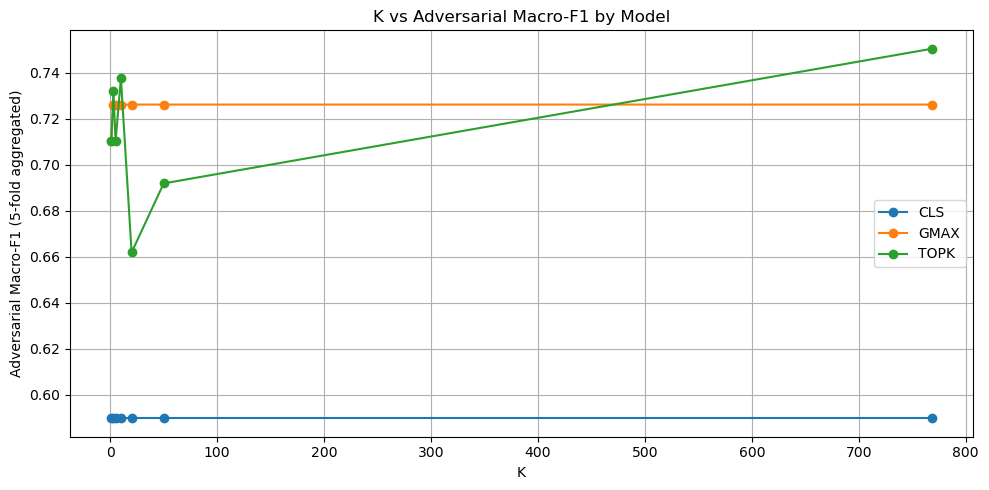

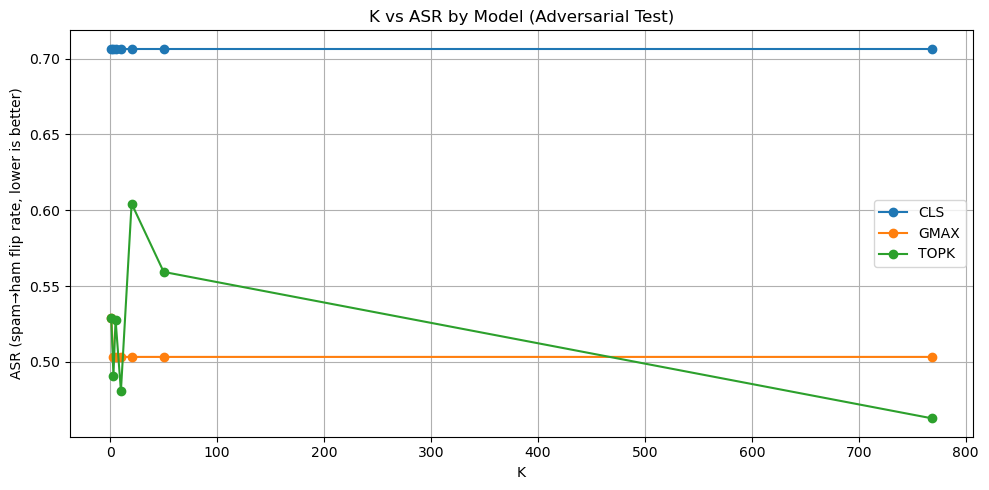

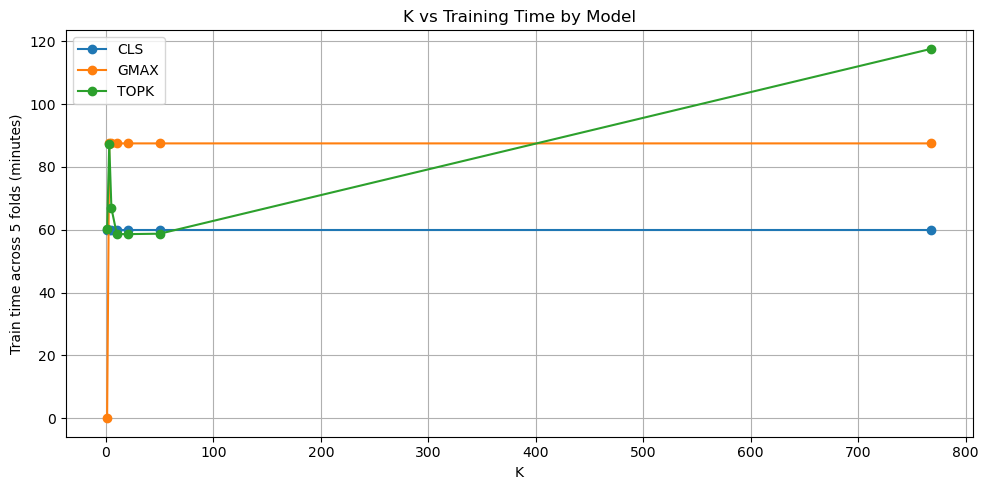

In [14]:
# =========================
# 12) Aggregate plots
# =========================
plot_df = summary_df.copy().sort_values(["k", "model_type"])

# 12.1 K vs Adversarial Macro-F1
plt.figure(figsize=(10, 5))
for model_type in ["cls", "gmax", "topk"]:
    sub = plot_df[plot_df["model_type"] == model_type].sort_values("k")
    if len(sub) == 0:
        continue
    plt.plot(sub["k"], sub["adv_macro_f1"], marker="o", label=model_type.upper())
plt.xlabel("K")
plt.ylabel("Adversarial Macro-F1 (5-fold aggregated)")
plt.title("K vs Adversarial Macro-F1 by Model")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "k_vs_adv_macro_f1_by_model.png"), dpi=200)
plt.show()

# 12.2 K vs Adversarial ASR
plt.figure(figsize=(10, 5))
for model_type in ["cls", "gmax", "topk"]:
    sub = plot_df[plot_df["model_type"] == model_type].sort_values("k")
    if len(sub) == 0:
        continue
    plt.plot(sub["k"], sub["adv_asr_spam_to_ham"], marker="o", label=model_type.upper())
plt.xlabel("K")
plt.ylabel("ASR (spam→ham flip rate, lower is better)")
plt.title("K vs ASR by Model (Adversarial Test)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "k_vs_adv_asr_by_model.png"), dpi=200)
plt.show()

# 12.3 K vs training time per model (sum over 5 folds)
plt.figure(figsize=(10, 5))
for model_type in ["cls", "gmax", "topk"]:
    sub = plot_df[plot_df["model_type"] == model_type].sort_values("k")
    if len(sub) == 0:
        continue
    plt.plot(sub["k"], sub["train_elapsed_minutes_sum_folds"], marker="o", label=model_type.upper())
plt.xlabel("K")
plt.ylabel("Train time across 5 folds (minutes)")
plt.title("K vs Training Time by Model")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "k_vs_train_time_by_model.png"), dpi=200)
plt.show()

# ## 13) ASR comparison plot for EACH FOLD (requested)
# This keeps the "ASR comparison" idea and shows it per fold across K values.
# We make one grouped-bar plot per fold with bars for CLS / GlobalMax / TopKAvg.

,k,fold_id,model_type,adv_asr_spam_to_ham,is_alias
0,1,1,cls,0.613974,False
1,1,1,gmax,0.508297,True
2,1,1,hybrid,0.731587,False
3,1,1,topk,0.508297,False
4,3,1,cls,0.613974,False
5,3,1,gmax,0.760699,False
6,3,1,hybrid,0.339738,False
7,3,1,topk,0.844541,False
8,5,1,cls,0.613974,False
9,5,1,gmax,0.760699,False


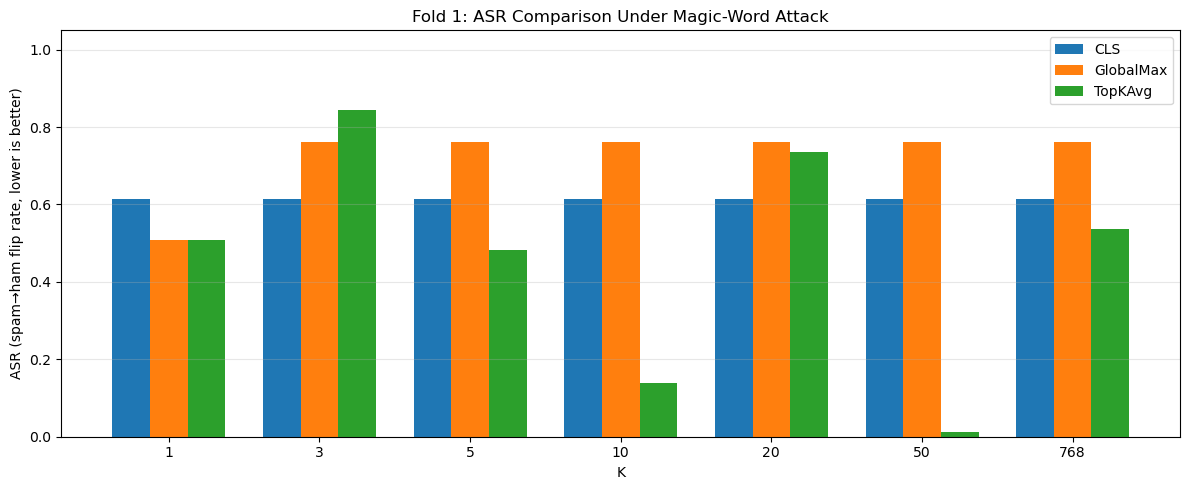

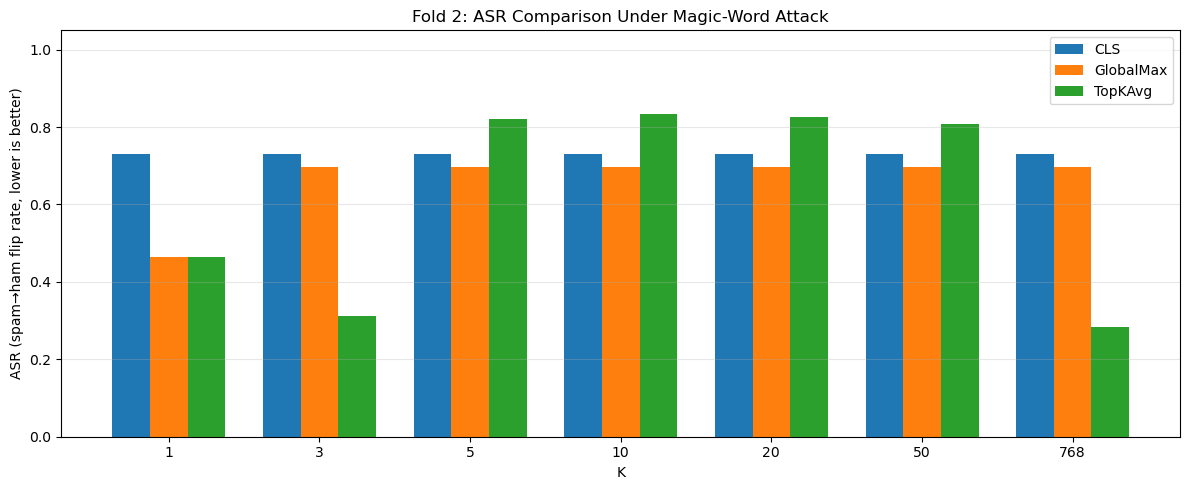

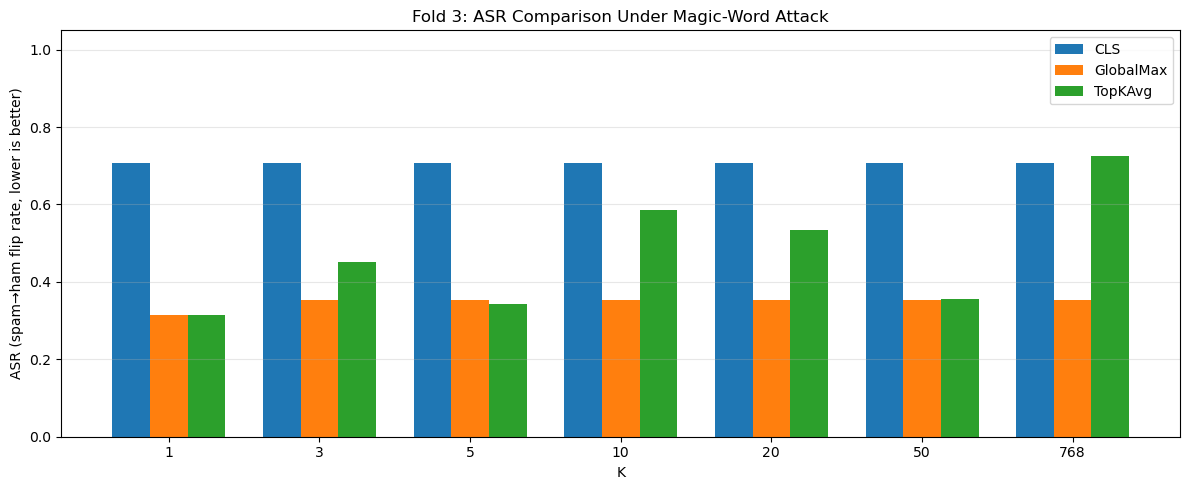

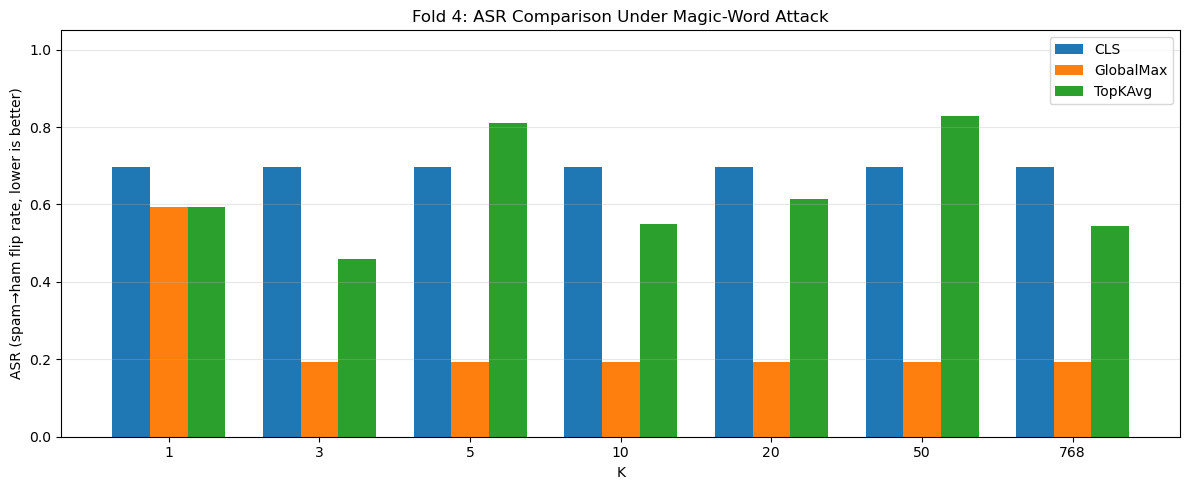

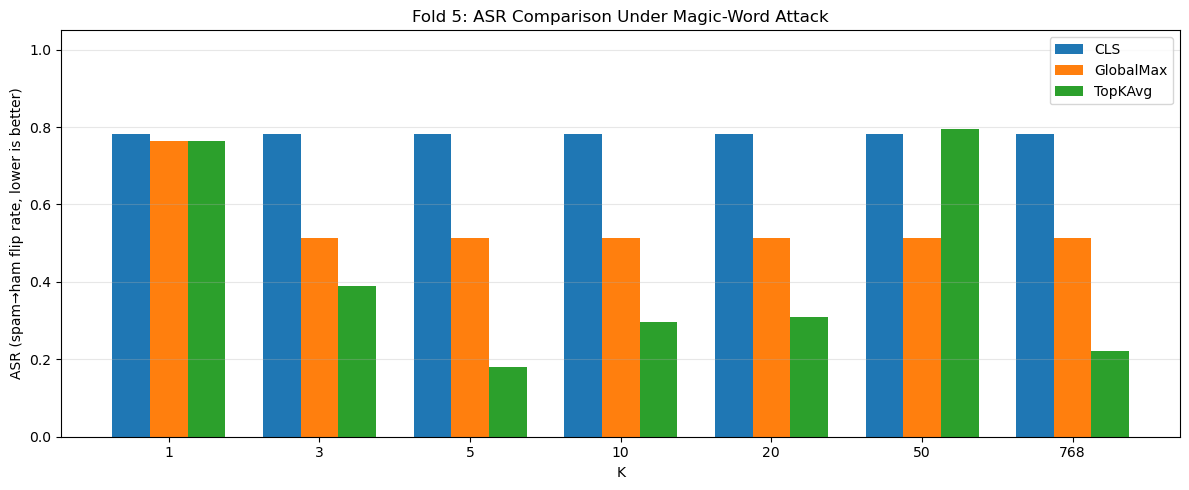

Per-fold ASR comparison plots saved in: spam_topk_adv_cv_outputs_concat_enron512/plots/per_fold_asr


In [15]:
# =========================
# 13) Per-fold ASR comparison plots (requested)
# =========================
asr_fold_df = asr_plot_df.copy()

# Ensure all alias rows exist for k=1 gmax (they should)
display(asr_fold_df.head(20))

for fold_id in sorted(asr_fold_df["fold_id"].unique()):
    sub = asr_fold_df[asr_fold_df["fold_id"] == fold_id].copy()

    # Pivot: rows=K, cols=model_type
    pv = sub.pivot_table(index="k", columns="model_type", values="adv_asr_spam_to_ham", aggfunc="mean")
    pv = pv.sort_index()

    # Reindex expected model order for consistent plotting
    for col in ["cls", "gmax", "topk"]:
        if col not in pv.columns:
            pv[col] = np.nan
    pv = pv[["cls", "gmax", "topk"]]

    x = np.arange(len(pv.index))
    width = 0.25

    plt.figure(figsize=(12, 5))
    plt.bar(x - width, pv["cls"].values, width=width, label="CLS")
    plt.bar(x,         pv["gmax"].values, width=width, label="GlobalMax")
    plt.bar(x + width, pv["topk"].values, width=width, label="TopKAvg")

    plt.xticks(x, [str(k) for k in pv.index])
    plt.ylim(0, 1.05)
    plt.xlabel("K")
    plt.ylabel("ASR (spam→ham flip rate, lower is better)")
    plt.title(f"Fold {fold_id}: ASR Comparison Under Magic-Word Attack")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()

    out_png = os.path.join(FOLD_PLOT_DIR, f"fold_{fold_id}_asr_comparison_by_k.png")
    plt.savefig(out_png, dpi=200)
    plt.show()

print(f"Per-fold ASR comparison plots saved in: {FOLD_PLOT_DIR}")

# ## 14) Final summary: best K for TopKAvg on adversarial metric

In [16]:
# =========================
# 14) Best K for TopKAvg
# =========================
topk_only = summary_df[summary_df["model_type"] == "topk"].sort_values("k")
if len(topk_only) > 0:
    best_f1_row = topk_only.loc[topk_only["adv_macro_f1"].idxmax()]
    best_asr_row = topk_only.loc[topk_only["adv_asr_spam_to_ham"].idxmin()]

    print("Best TopK by adversarial Macro-F1:")
    display(best_f1_row.to_frame().T)

    print("Best TopK by adversarial ASR (lower is better):")
    display(best_asr_row.to_frame().T)

Best TopK by adversarial Macro-F1:


,k,model_type,is_alias,alias_of,global_max_equivalent,train_elapsed_seconds_sum_folds,train_elapsed_minutes_sum_folds,clean_accuracy,clean_macro_precision,clean_macro_recall,...,adv_accuracy,adv_macro_precision,adv_macro_recall,adv_macro_f1,adv_weighted_f1,adv_asr_spam_to_ham,adv_cm_00,adv_cm_01,adv_cm_10,adv_cm_11
27,768,topk,False,,False,7055.286193,117.588103,0.993831,0.993805,0.993857,...,0.762012,0.833067,0.766264,0.750501,0.749506,0.462757,16467,78,7946,9225


Best TopK by adversarial ASR (lower is better):


,k,model_type,is_alias,alias_of,global_max_equivalent,train_elapsed_seconds_sum_folds,train_elapsed_minutes_sum_folds,clean_accuracy,clean_macro_precision,clean_macro_recall,...,adv_accuracy,adv_macro_precision,adv_macro_recall,adv_macro_f1,adv_weighted_f1,adv_asr_spam_to_ham,adv_cm_00,adv_cm_01,adv_cm_10,adv_cm_11
27,768,topk,False,,False,7055.286193,117.588103,0.993831,0.993805,0.993857,...,0.762012,0.833067,0.766264,0.750501,0.749506,0.462757,16467,78,7946,9225


# ## 15) McNemar's test (K=5): TopK vs CLS and TopK vs GlobalMax

This section runs **McNemar's test** for **K=5** using pooled out-of-fold test predictions across all CV folds.

Comparisons run:
- **TopK (K=5) vs CLS**
- **TopK (K=5) vs GlobalMax (MaxPool)**

For each comparison, the notebook computes McNemar on:
- **clean test predictions**
- **adversarial test predictions**

> This cell reuses `evaluate_one_fold_model(...)` and `fold_cache`.  
> If the main experiment has already been run, CLS/GMAX may be reused from `MODEL_RUN_CACHE` (if available).

In [ ]:
# =========================
# 15) McNemar helper + run (K=5, TopK vs CLS only)
# =========================

MCNEMAR_K = 5
MCNEMAR_COMPARE_PAIRS = [("topk", "cls")]  # only TopK(K=5) vs CLS
MCNEMAR_SPLITS = ["clean", "adv"]  # run both clean and adversarial

# Separate cache for this section so we don't rerun the same fold/model unnecessarily
MCNEMAR_FOLD_OUT_CACHE = {}

def _safe_np(a):
    import numpy as _np
    if isinstance(a, _np.ndarray):
        return a
    return _np.asarray(list(a))

def _get_test_meta_from_fc(fc, split_name):
    """
    Returns a meta df aligned to the test set row order used by evaluate_one_fold_model.
    We preserve a stable sample identifier if available; otherwise we use positional index.
    """
    if split_name == "clean":
        df = fc["df_test_clean"].copy()
    elif split_name == "adv":
        df = fc["df_test_adv"].copy()
    else:
        raise ValueError(f"Unknown split_name: {split_name}")

    df = df.reset_index(drop=True).copy()

    if "sample_id" in df.columns:
        sid = df["sample_id"].tolist()
    else:
        # Fallback: use row position within fold test set (valid for paired comparisons across models)
        sid = list(range(len(df)))

    # y_true may exist in dataframe but we trust the model output labels for exact loader alignment.
    return pd.DataFrame({
        "sample_pos": list(range(len(df))),
        "sample_id": sid,
    })

def _get_fold_out_for_mcnemar(fc, model_type, k_value=MCNEMAR_K):
    """
    Calls evaluate_one_fold_model and caches result for this McNemar section.
    model_type: 'topk' | 'cls' | 'gmax'
    """
    key = (int(fc["fold_id"]), str(model_type).lower(), int(k_value) if k_value is not None else None)
    if key in MCNEMAR_FOLD_OUT_CACHE:
        return MCNEMAR_FOLD_OUT_CACHE[key]

    out = evaluate_one_fold_model(fc, model_type=model_type, k_value=k_value, verbose=False)
    MCNEMAR_FOLD_OUT_CACHE[key] = out
    return out

def build_all_predictions_for_mcnemar_k5(fold_cache, k_value=MCNEMAR_K, model_types=("topk", "cls", "gmax")):
    """
    Build pooled per-sample predictions for K=5 McNemar tests across all folds.
    Produces one row per (fold, split, model_type, sample_pos).
    """
    rows = []

    for fc in fold_cache:
        fold_id = int(fc["fold_id"])

        for model_type in model_types:
            out = _get_fold_out_for_mcnemar(fc, model_type=model_type, k_value=k_value)

            # CLEAN
            meta_clean = _get_test_meta_from_fc(fc, "clean")
            y_true_clean = _safe_np(out["y_true_clean"])
            y_pred_clean = _safe_np(out["y_pred_clean"])
            if len(meta_clean) != len(y_true_clean) or len(y_true_clean) != len(y_pred_clean):
                raise ValueError(
                    f"Length mismatch (clean) fold={fold_id}, model={model_type}: "
                    f"meta={len(meta_clean)}, y_true={len(y_true_clean)}, y_pred={len(y_pred_clean)}"
                )

            rows.extend(pd.DataFrame({
                "fold_id": fold_id,
                "split": "clean",
                "model_type": str(model_type).lower(),
                "k": int(k_value) if str(model_type).lower() == "topk" else np.nan,
                "sample_pos": meta_clean["sample_pos"].values,
                "sample_id": meta_clean["sample_id"].values,
                "y_true": y_true_clean.astype(int),
                "y_pred": y_pred_clean.astype(int),
            }).to_dict("records"))

            # ADVERSARIAL
            meta_adv = _get_test_meta_from_fc(fc, "adv")
            y_true_adv = _safe_np(out["y_true_adv"])
            y_pred_adv = _safe_np(out["y_pred_adv"])
            if len(meta_adv) != len(y_true_adv) or len(y_true_adv) != len(y_pred_adv):
                raise ValueError(
                    f"Length mismatch (adv) fold={fold_id}, model={model_type}: "
                    f"meta={len(meta_adv)}, y_true={len(y_true_adv)}, y_pred={len(y_pred_adv)}"
                )

            rows.extend(pd.DataFrame({
                "fold_id": fold_id,
                "split": "adv",
                "model_type": str(model_type).lower(),
                "k": int(k_value) if str(model_type).lower() == "topk" else np.nan,
                "sample_pos": meta_adv["sample_pos"].values,
                "sample_id": meta_adv["sample_id"].values,
                "y_true": y_true_adv.astype(int),
                "y_pred": y_pred_adv.astype(int),
            }).to_dict("records"))

    pred_df = pd.DataFrame(rows).sort_values(
        ["split", "fold_id", "model_type", "sample_pos"]
    ).reset_index(drop=True)

    return pred_df

def _mcnemar_contingency(df_pair):
    """
    df_pair columns: y_true, y_pred_a, y_pred_b
    Table:
      [[a, b],
       [c, d]]
    where
      a = both correct
      b = A correct, B wrong
      c = A wrong, B correct
      d = both wrong
    """
    a_ok = (df_pair["y_pred_a"].values == df_pair["y_true"].values)
    b_ok = (df_pair["y_pred_b"].values == df_pair["y_true"].values)

    a = int(np.sum(a_ok & b_ok))
    b = int(np.sum(a_ok & (~b_ok)))
    c = int(np.sum((~a_ok) & b_ok))
    d = int(np.sum((~a_ok) & (~b_ok)))
    table = np.array([[a, b], [c, d]], dtype=int)
    return table, a, b, c, d

def run_mcnemar_from_pred_df(pred_df, split_name, model_a, model_b, k_topk=MCNEMAR_K, exact_threshold=25):
    """
    Runs pooled McNemar across all folds for one split and one model pair.
    model_a/model_b should be in {'topk','cls','gmax'}.
    """
    a_df = pred_df[(pred_df["split"] == split_name) & (pred_df["model_type"] == model_a)].copy()
    b_df = pred_df[(pred_df["split"] == split_name) & (pred_df["model_type"] == model_b)].copy()

    # K applies only to topk rows
    if model_a == "topk":
        a_df = a_df[a_df["k"] == int(k_topk)].copy()
    if model_b == "topk":
        b_df = b_df[b_df["k"] == int(k_topk)].copy()

    a_df = a_df[["fold_id", "sample_pos", "sample_id", "y_true", "y_pred"]].rename(columns={"y_pred": "y_pred_a"})
    b_df = b_df[["fold_id", "sample_pos", "sample_id", "y_true", "y_pred"]].rename(columns={"y_pred": "y_pred_b"})

    pair_df = a_df.merge(
        b_df,
        on=["fold_id", "sample_pos", "sample_id", "y_true"],
        how="inner",
        validate="one_to_one"
    )

    if pair_df.empty:
        raise ValueError(f"No paired rows found for split={split_name}, {model_a} vs {model_b}")

    table, a, b, c, d = _mcnemar_contingency(pair_df)

    # Prefer statsmodels, fall back to scipy/manual
    method = None
    statistic = None
    pvalue = None

    try:
        from statsmodels.stats.contingency_tables import mcnemar as _sm_mcnemar
        use_exact = (b + c) < exact_threshold
        res = _sm_mcnemar(table, exact=use_exact, correction=not use_exact)
        pvalue = float(res.pvalue)
        statistic = None if use_exact else float(res.statistic)
        method = "exact binomial" if use_exact else "chi-square (continuity-corrected)"
    except Exception:
        if (b + c) == 0:
            pvalue = 1.0
            statistic = 0.0
            method = "degenerate (no disagreements)"
        elif (b + c) < exact_threshold:
            try:
                from scipy.stats import binomtest
                pvalue = float(binomtest(k=min(b, c), n=b+c, p=0.5, alternative="two-sided").pvalue)
                statistic = None
                method = "exact binomial (scipy fallback)"
            except Exception:
                # conservative fallback if scipy unavailable
                pvalue = np.nan
                statistic = np.nan
                method = "exact binomial unavailable (install statsmodels/scipy)"
        else:
            # continuity-corrected chi-square
            num = (abs(b - c) - 1.0)
            statistic = float((num * num) / float(b + c))
            try:
                from scipy.stats import chi2
                pvalue = float(1 - chi2.cdf(statistic, df=1))
                method = "chi-square corrected (scipy fallback)"
            except Exception:
                pvalue = np.nan
                method = "chi-square stat only (scipy unavailable)"

    if b > c:
        direction = f"{model_a} better than {model_b}"
    elif c > b:
        direction = f"{model_b} better than {model_a}"
    else:
        direction = "tie on disagreements"

    summary = {
        "k_topk": int(k_topk),
        "split": split_name,
        "model_a": model_a,
        "model_b": model_b,
        "n_pairs": int(len(pair_df)),
        "both_correct_a": int(a),
        "a_correct_b_wrong": int(b),   # McNemar 'b'
        "a_wrong_b_correct": int(c),   # McNemar 'c'
        "both_wrong_d": int(d),
        "disagreements_b_plus_c": int(b + c),
        "method": method,
        "statistic": statistic,
        "pvalue": pvalue,
        "direction": direction,
        "win_rate_a_among_disagreements": (float(b) / float(b + c)) if (b + c) > 0 else np.nan,
    }

    return summary, table, pair_df

# ---------- Build per-sample predictions (K=5 for TopK, plus CLS/GMAX) ----------
mcnemar_pred_df = build_all_predictions_for_mcnemar_k5(
    fold_cache=fold_cache,
    k_value=MCNEMAR_K,
    model_types=("topk", "cls", "gmax"),
)

print("McNemar prediction rows (pooled across folds):", len(mcnemar_pred_df))
display(mcnemar_pred_df.head(12))

# ---------- Run requested McNemar comparisons ----------
mcnemar_rows = []
mcnemar_tables = []
pair_cache_for_inspection = {}  # optional: inspect pairwise merged rows later

for split_name in MCNEMAR_SPLITS:
    for model_a, model_b in MCNEMAR_COMPARE_PAIRS:
        summary, table, pair_df = run_mcnemar_from_pred_df(
            pred_df=mcnemar_pred_df,
            split_name=split_name,
            model_a=model_a,
            model_b=model_b,
            k_topk=MCNEMAR_K,
        )
        mcnemar_rows.append(summary)
        mcnemar_tables.append({
            "k_topk": int(MCNEMAR_K),
            "split": split_name,
            "model_a": model_a,
            "model_b": model_b,
            "table_00_both_correct": int(table[0, 0]),
            "table_01_a_correct_b_wrong": int(table[0, 1]),
            "table_10_a_wrong_b_correct": int(table[1, 0]),
            "table_11_both_wrong": int(table[1, 1]),
        })
        pair_cache_for_inspection[(split_name, model_a, model_b)] = pair_df

mcnemar_k5_df = pd.DataFrame(mcnemar_rows)
mcnemar_k5_tables_df = pd.DataFrame(mcnemar_tables)

# ---------- (Optional) Holm correction across the 4 tests (2 pairs x 2 splits) ----------
try:
    from statsmodels.stats.multitest import multipletests
    valid_mask = mcnemar_k5_df["pvalue"].notna()
    if valid_mask.any():
        rej, p_corr, _, _ = multipletests(mcnemar_k5_df.loc[valid_mask, "pvalue"], method="holm")
        mcnemar_k5_df.loc[valid_mask, "pvalue_holm"] = p_corr
        mcnemar_k5_df.loc[valid_mask, "significant_holm_0p05"] = rej
except Exception as _e:
    print("Holm correction skipped:", _e)

# ---------- Save outputs ----------
mcnemar_pred_csv = os.path.join(OUT_DIR, f"mcnemar_k{MCNEMAR_K}_predictions.csv")
mcnemar_res_csv = os.path.join(OUT_DIR, f"mcnemar_k{MCNEMAR_K}_results.csv")
mcnemar_tbl_csv = os.path.join(OUT_DIR, f"mcnemar_k{MCNEMAR_K}_tables.csv")

mcnemar_pred_df.to_csv(mcnemar_pred_csv, index=False)
mcnemar_k5_df.to_csv(mcnemar_res_csv, index=False)
mcnemar_k5_tables_df.to_csv(mcnemar_tbl_csv, index=False)

print("\nSaved McNemar outputs:")
print(" -", mcnemar_pred_csv)
print(" -", mcnemar_res_csv)
print(" -", mcnemar_tbl_csv)

print("\nMcNemar results (K=5):")
display(mcnemar_k5_df)

print("\nContingency tables:")
display(mcnemar_k5_tables_df)

# Pretty print each test
for _, r in mcnemar_k5_df.iterrows():
    print("\n" + "="*80)
    print(f"McNemar (K={int(r['k_topk'])}) | split={r['split']} | {r['model_a']} vs {r['model_b']}")
    print(f"n_pairs={int(r['n_pairs'])}, disagreements={int(r['disagreements_b_plus_c'])}")
    print(f"b (A correct, B wrong) = {int(r['a_correct_b_wrong'])}")
    print(f"c (A wrong, B correct) = {int(r['a_wrong_b_correct'])}")
    print(f"method={r['method']}")
    print(f"pvalue={r['pvalue']}")
    if "pvalue_holm" in mcnemar_k5_df.columns:
        print(f"pvalue_holm={r.get('pvalue_holm', np.nan)} | significant_holm_0p05={r.get('significant_holm_0p05', np.nan)}")
    print(f"direction={r['direction']}")

Train epoch 1/2:   0%|          | 0/317 [00:00<?, ?it/s]

Train epoch 2/2:   0%|          | 0/317 [00:00<?, ?it/s]

Train epoch 1/2:   0%|          | 0/317 [00:00<?, ?it/s]

Train epoch 2/2:   0%|          | 0/317 [00:00<?, ?it/s]

Train epoch 1/2:   0%|          | 0/317 [00:00<?, ?it/s]

...

,k_topk,split,model_a,model_b,n_pairs,both_correct_a,a_correct_b_wrong,a_wrong_b_correct,both_wrong_d,disagreements_b_plus_c,method,statistic,pvalue,direction,win_rate_a_among_disagreements,pvalue_holm,significant_holm_0p05
0,5,clean,topk,cls,33716,33376,159,95,86,254,chi-square (continuity-corrected),15.625984,7.718661e-05,topk better than cls,0.625984,7.718661e-05,True
1,5,adv,topk,cls,33716,20184,3788,1274,8470,5062,chi-square (continuity-corrected),1247.564006,2.808532e-273,topk better than cls,0.748321,5.617064e-273,True



Contingency tables:


,k_topk,split,model_a,model_b,table_00_both_correct,table_01_a_correct_b_wrong,table_10_a_wrong_b_correct,table_11_both_wrong
0,5,clean,topk,cls,33376,159,95,86
1,5,adv,topk,cls,20184,3788,1274,8470



McNemar (K=5) | split=clean | topk vs cls
n_pairs=33716, disagreements=254
b (A correct, B wrong) = 159
c (A wrong, B correct) = 95
method=chi-square (continuity-corrected)
pvalue=7.718661022466607e-05
pvalue_holm=7.718661022466607e-05 | significant_holm_0p05=True
direction=topk better than cls

McNemar (K=5) | split=adv | topk vs cls
n_pairs=33716, disagreements=5062
b (A correct, B wrong) = 3788
c (A wrong, B correct) = 1274
method=chi-square (continuity-corrected)
pvalue=2.808531769373136e-273
pvalue_holm=5.617063538746272e-273 | significant_holm_0p05=True
direction=topk better than cls


: 